# Exploratory Data Analysis (EDA)

In [1]:
# Automatically reloads modules when you make changes (useful during development)
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import sys, os
sys.path.append(os.path.abspath('..'))

from src.data import load_data
df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl, df_holidays = load_data()

In [3]:
from week1_Yuri import features

df_title_features = df_title["PROPERTIES"].apply(lambda s: [float(x) for x in s.split(",")])
features_title_df = pd.DataFrame(df_title_features.tolist(), columns=features, index=df_title.index)
df_title_prop = pd.concat([df_title.drop(columns=["PROPERTIES"]), features_title_df], axis=1)
df_title_prop.head()

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,Number of characters,Number of characters without counting white space,Fraction of alphabetical characters,Fraction of digits,Fraction of uppercase characters,...,LIWC_Achiev,LIWC_Leisure,LIWC_Home,LIWC_Money,LIWC_Relig,LIWC_Death,LIWC_Assent,LIWC_Dissent,LIWC_Nonflu,LIWC_Filler
0,rddtgaming,rddtrust,1u4pzzs,2013-12-31 16:39:18,1,25.0,23.0,0.760000,0.00,0.440000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,xboxone,battlefield_4,1u4tmfs,2013-12-31 17:59:11,1,100.0,88.0,0.780000,0.02,0.080000,...,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ps4,battlefield_4,1u4tmos,2013-12-31 17:59:40,1,100.0,88.0,0.780000,0.02,0.080000,...,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,fitnesscirclejerk,leangains,1u50xfs,2013-12-31 19:01:56,1,49.0,43.0,0.775510,0.00,0.265306,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,fitnesscirclejerk,lifeprotips,1u51nps,2013-12-31 21:02:28,1,14.0,14.0,0.785714,0.00,0.428571,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df_body_features = df_body["PROPERTIES"].apply(lambda s: [float(x) for x in s.split(",")])
features_body_df = pd.DataFrame(df_body_features.tolist(), columns=features, index=df_body.index)
df_body_prop = pd.concat([df_body.drop(columns=["PROPERTIES"]), features_body_df], axis=1)
df_body_prop.head()

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,Number of characters,Number of characters without counting white space,Fraction of alphabetical characters,Fraction of digits,Fraction of uppercase characters,...,LIWC_Achiev,LIWC_Leisure,LIWC_Home,LIWC_Money,LIWC_Relig,LIWC_Death,LIWC_Assent,LIWC_Dissent,LIWC_Nonflu,LIWC_Filler
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,345.0,298.0,0.756522,0.017391,0.086957,...,0.068966,0.034483,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,101.0,98.0,0.742574,0.019802,0.049505,...,0.000000,0.066667,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,85.0,85.0,0.752941,0.023529,0.082353,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,nfl,cfb,1u4sjvs,2013-12-31 17:37:55,1,1124.0,949.0,0.772242,0.001779,0.057829,...,0.031250,0.020833,0.0,0.0,0.0,0.0,0.0,0.0,0.020833,0.005208
4,playmygame,gamedev,1u4w5ss,2014-01-01 02:51:13,1,715.0,622.0,0.777622,0.006993,0.025175,...,0.016667,0.025000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.008333


In [5]:
from src.preprocessing import filter_active_subreddits
active_subreddits, total_counts = filter_active_subreddits(df_body, df_title, df_subreddits)

In [6]:
# Define multiple themes
THEMES = {
    'sports': [
        'nba', 'nfl', 'hockey', 'fantasyfootball', 'cfb', 'maddenultimateteam', 'baseball', 'golf', 'patriots', 'collegebasketball', 'seahawks', 'minnesotavikings', 'madden', 'greenbaypackers', 'warriors', 'eagles', 'denverbroncos', 'torontobluejays', '49ers', 'lakers', 'browns', 'oaklandraiders'
    ],
    'politics': [
        'the_donald', 'politic', 'conspiracy', 'conservative', 'worldpolitics', 'libertarian', 'mensrights', 'new_right', 'theredpill', 'anarcho_capitalism', 'whiterights', 'european', 'politicalvideo', 'metacanada', 'hillaryforprison', 'uncensorednews', 'asktrumpsupporters', 'altnewz', 'kossacks_for_sanders', 'wayofthebern', 'republican', 'conservatives'
    ],
    'gaming' : [
        'gaming', 'pcmasterrace', 'ps4', 'xboxone', 'games', 'rainbow6', 'minecraft', 'fo4', 'darksouls3', 'thedivision', 'fallout', 'dayz', 'halo', 'darksouls2', 'skyrim', 'grandtheftautov', 'oculus', 'witcher', 'kerbalspaceprogram', 'battlefield_one', 'battlefield_4', 'globaloffensivetrade', 'fireteams', 'rocketleagueexchange', 'dota2', 'leagueoflegends', 'globaloffensive', 'destinythegame', 'overwatch', 'hearthstone', 'wow', '2007scape', 'pokemongo', 'smite', 'runescape'
    ],
    'soccer': [
        'soccer', 'football', 'premierleague', 'realmadrid', 'liverpoolfc', 'chelseafc', 'barca', 'fifa', 'coys', 'gunners', 'reddevils', 'soccerstreams', 'bayernmunich', 'fcbayern', 'juventus', 'soccerbetting', 'atletico', 'tottenham', 'epl', 'laliga'
    ]
}

In [7]:
for theme_name, subreddit_list in THEMES.items():
    print(f"Processing theme: {theme_name} with {len(subreddit_list)} subreddits")
    # print(len(df_subreddits[df_subreddits['SUBREDDIT'].isin(subreddit_list)]))


Processing theme: sports with 22 subreddits
Processing theme: politics with 22 subreddits
Processing theme: gaming with 35 subreddits
Processing theme: soccer with 20 subreddits


In [8]:
# Define columns to display
columns_show = ['SUBREDDIT', 'POST_COUNT_SOURCE', 'POST_COUNT_TARGET', 'POST_COUNT_TOTAL']
for theme, subreddits in THEMES.items():

    neighbors = pd.read_csv(f'../data/{theme}_max_similarity_neighbors.csv')
    neighbors_subreddits = neighbors['SUBREDDIT'].tolist()
    total_subreddits = subreddits + neighbors['SUBREDDIT'].tolist()

    # Filter total_counts and get top 5 by total post count
    cluster_stats = (
        total_counts[total_counts['SUBREDDIT'].isin(total_subreddits)]
        .sort_values(by='POST_COUNT_TOTAL', ascending=False)
        [columns_show]
    )
    print(f"\n{'='*60}")
    print(f"Theme '{theme}' (n= {len(subreddits)+len(neighbors_subreddits)}, seeds {len(subreddits)} + neigbors {len(neighbors_subreddits)})")
    print(f"{'='*60}")
    display(cluster_stats.head(10))
    print("Top 10 subreddits:", cluster_stats.head(10)["SUBREDDIT"].tolist())


Theme 'sports' (n= 122, seeds 22 + neigbors 100)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
31007,nfl,997.0,4000.0,4997.0
20603,hockey,854.0,2962.0,3816.0
30456,nba,598.0,3042.0,3640.0
4376,baseball,575.0,1785.0,2360.0
8045,cfb,380.0,1561.0,1941.0
9373,collegebasketball,135.0,706.0,841.0
31010,nfl_draft,173.0,538.0,711.0
32151,oaklandraiders,415.0,258.0,673.0
19107,greenbaypackers,428.0,244.0,672.0
8315,chibears,350.0,318.0,668.0


Top 10 subreddits: ['nfl', 'hockey', 'nba', 'baseball', 'cfb', 'collegebasketball', 'nfl_draft', 'oaklandraiders', 'greenbaypackers', 'chibears']

Theme 'politics' (n= 122, seeds 22 + neigbors 100)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
9770,conspiracy,3850.0,3950.0,7800.0
44696,the_donald,2749.0,4487.0,7236.0
40398,shitstatistssay,4504.0,221.0,4725.0
1936,anarcho_capitalism,2045.0,1714.0,3759.0
28076,mensrights,1305.0,1341.0,2646.0
25867,libertarian,1048.0,1276.0,2324.0
40374,shitpoliticssays,2003.0,206.0,2209.0
45316,theredpill,200.0,1745.0,1945.0
28142,metacanada,1406.0,286.0,1692.0
9741,conservative,316.0,1089.0,1405.0


Top 10 subreddits: ['conspiracy', 'the_donald', 'shitstatistssay', 'anarcho_capitalism', 'mensrights', 'libertarian', 'shitpoliticssays', 'theredpill', 'metacanada', 'conservative']

Theme 'gaming' (n= 135, seeds 35 + neigbors 100)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
17680,gaming,2072.0,6097.0,8169.0
25392,leagueoflegends,1346.0,4856.0,6202.0
33656,pcmasterrace,1093.0,3702.0,4795.0
12854,dota2,1123.0,2591.0,3714.0
17627,games,1122.0,2200.0,3322.0
18569,globaloffensive,687.0,2128.0,2815.0
20108,hearthstone,710.0,1601.0,2311.0
11975,destinythegame,558.0,1399.0,1957.0
33103,overwatch,597.0,1350.0,1947.0
32257,oculus,719.0,1063.0,1782.0


Top 10 subreddits: ['gaming', 'leagueoflegends', 'pcmasterrace', 'dota2', 'games', 'globaloffensive', 'hearthstone', 'destinythegame', 'overwatch', 'oculus']

Theme 'soccer' (n= 120, seeds 20 + neigbors 100)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
41492,soccer,942.0,3775.0,4717.0
37167,reddevils,319.0,213.0,532.0
41521,soccerstreams,1.0,520.0,521.0
19439,gunners,262.0,162.0,424.0
26250,liverpoolfc,186.0,188.0,374.0
3532,atletico,331.0,23.0,354.0
8260,chelseafc,196.0,99.0,295.0
15691,fifa,130.0,138.0,268.0
4336,barca,210.0,37.0,247.0
10142,coys,143.0,80.0,223.0


Top 10 subreddits: ['soccer', 'reddevils', 'soccerstreams', 'gunners', 'liverpoolfc', 'atletico', 'chelseafc', 'fifa', 'barca', 'coys']


In [19]:
df_title[df_title["SOURCE_SUBREDDIT"]=="leagueoflegends"].TARGET_SUBREDDIT.value_counts().head(10)

TARGET_SUBREDDIT
dota2              43
summonerschool     30
leagueofmeta       25
clg                20
globaloffensive    19
askreddit          15
gaming             13
starcraft           9
liquidlegends       9
gangplankmains      7
Name: count, dtype: int64

In [20]:
df_body[df_body["SOURCE_SUBREDDIT"]=="leagueoflegends"].TARGET_SUBREDDIT.value_counts().head(10)

TARGET_SUBREDDIT
summonerschool      133
loleventvods         63
dota2                41
teamredditteams      39
globaloffensive      27
lolchampconcepts     21
askreddit            19
soccer               15
smite                13
heroesofthestorm     13
Name: count, dtype: int64

In [ ]:
df_title[df_title["SOURCE_SUBREDDIT"]=="the_donald"].TARGET_SUBREDDIT.value_counts().head(10)

In [17]:
df_body[df_body["SOURCE_SUBREDDIT"]=="the_donald"].TARGET_SUBREDDIT.value_counts().head(10)

TARGET_SUBREDDIT
worldnews              22
politics               20
conspiracy             13
dncleaks               13
news                   12
askthe_donald          11
iama                    9
askreddit               9
asktrumpsupporters      9
sandersforpresident     8
Name: count, dtype: int64

### Sentiment andLIWC attributes

Identify the dominant features for each group

In [9]:
features[:18]

['Number of characters',
 'Number of characters without counting white space',
 'Fraction of alphabetical characters',
 'Fraction of digits',
 'Fraction of uppercase characters',
 'Fraction of white spaces',
 'Fraction of special characters (e.g., comma, exclamation mark, etc.)',
 'Number of words',
 'Number of unique words',
 'Number of long words (at least 6 characters)',
 'Average word length',
 'Number of unique stopwords',
 'Fraction of stopwords',
 'Number of sentences',
 'Number of long sentences (at least 10 words)',
 'Average number of characters per sentence',
 'Average number of words per sentence',
 'Automated readability index']

In [10]:
from week1_Yuri import get_dataframe_features
subreddits_list = [
    'conspiracy', 'the_donald', 'shitstatistssay', 'anarcho_capitalism', 'mensrights', 
    'libertarian', 'shitpoliticssays', 'theredpill', 'metacanada', 'conservative'
    ]
df_features_sentiment, df_features_liwc = get_dataframe_features(df_title_prop, df_body_prop, subreddits_list)

In [11]:
df_features_sentiment

,Feature,Mean_Title,Max_Title,Sum_Title,Std_Title,Mean_Body,Max_Body,Sum_Body,Std_Body
0,Positive sentiment (VADER),0.08758,0.82,2418.49,0.12325,0.08451,0.80,593.21,0.07404
1,Negative sentiment (VADER),0.11284,0.85,3116.04,0.14286,0.08296,0.82,582.27,0.07659
2,Compound sentiment (VADER),-0.07254,0.97,-2003.07,0.44376,-0.02393,1.00,-167.94,0.71552


In [12]:
df_features_liwc.sort_values(by=['Sum_Title', 'Sum_Body'], ascending=False).head(20)

,Feature,Mean_Title,Max_Title,Sum_Title,Std_Title,Mean_Body,Max_Body,Sum_Body,Std_Body
3,LIWC_Funct,0.33275,0.75,9188.78,0.13882,0.35142,0.65,2466.63,0.16502
35,LIWC_CogMech,0.11029,0.60,3045.68,0.08472,0.11668,0.42,818.96,0.06094
19,LIWC_Prep,0.10037,0.46,2771.76,0.06558,0.08927,0.21,626.60,0.04546
53,LIWC_Relativ,0.08866,0.56,2448.42,0.07663,0.07811,0.30,548.25,0.04477
13,LIWC_Verbs,0.08148,0.50,2250.20,0.06781,0.07921,0.24,555.96,0.04415
25,LIWC_Social,0.06737,0.50,1860.34,0.06904,0.08227,0.25,577.48,0.03359
4,LIWC_Pronoun,0.05991,0.50,1654.43,0.06530,0.07827,0.28,549.35,0.04962
29,LIWC_Affect,0.05747,0.50,1586.98,0.06278,0.04057,0.19,284.77,0.02865
16,LIWC_Present,0.05605,0.48,1547.94,0.05644,0.04878,0.18,342.40,0.03179
12,LIWC_Article,0.05163,0.33,1425.83,0.05166,0.04813,0.17,337.81,0.02958


### Spikes and trends of selected features over time for a given subreddits

Title


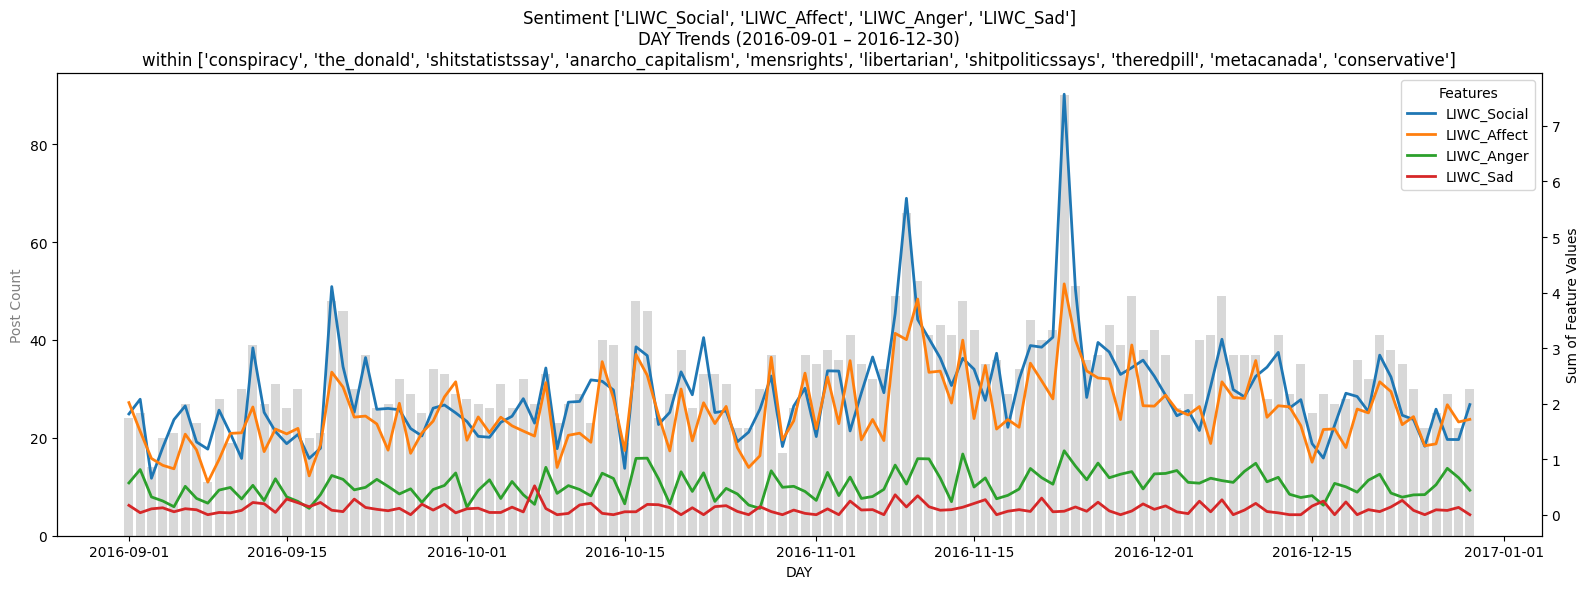

Body


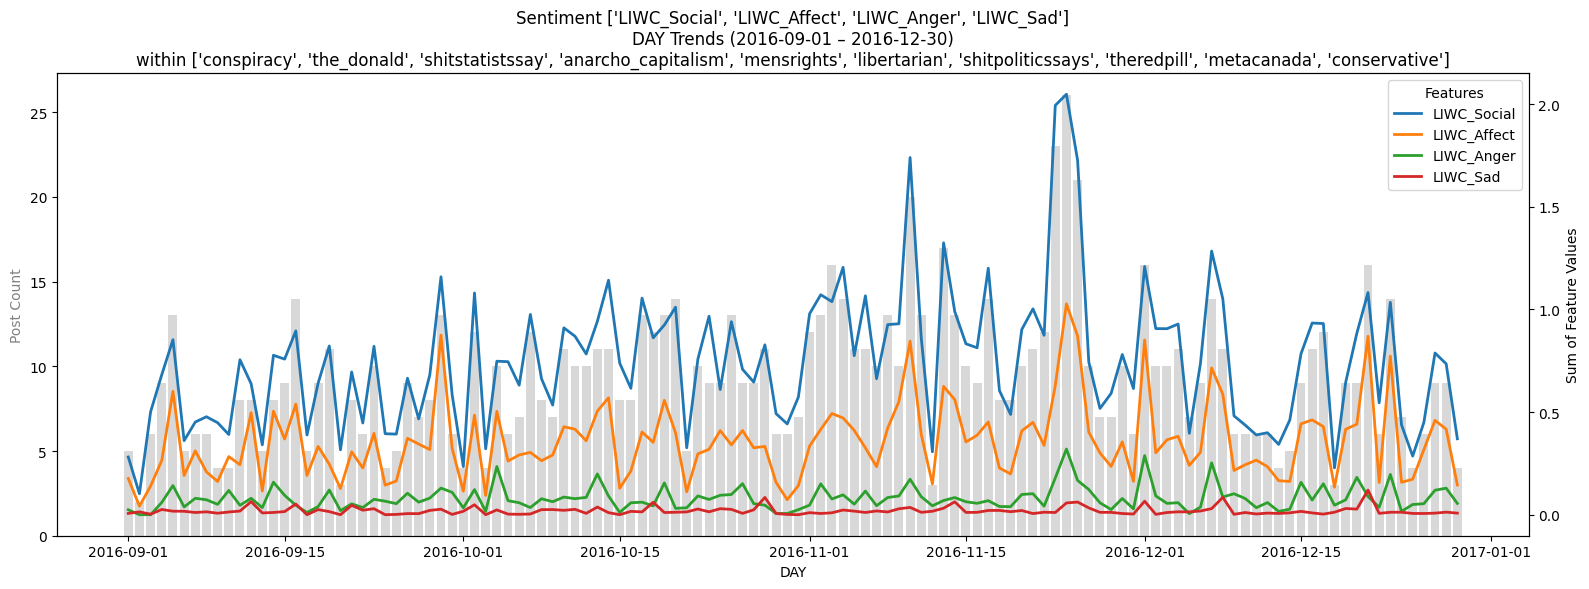

In [15]:
from week1_Yuri import plot_subreddits_features_trend 
subreddits_list = [
    'conspiracy', 'the_donald', 'shitstatistssay', 'anarcho_capitalism', 'mensrights', 
    'libertarian', 'shitpoliticssays', 'theredpill', 'metacanada', 'conservative'
    ]
start_time = "2016-09-01"
end_time = "2016-12-30"
features_list = [
    "LIWC_Social",
    "LIWC_Affect",
    "LIWC_Anger",
    "LIWC_Sad",
]
period = "D"  # "D" for daily, "W" for weekly, "M" for monthly, "Q" for quarterly, "Y" for yearly
print("Title")
plot_subreddits_features_trend(df_title_prop, subreddits_list, start_time, end_time, features_list, period)
print("Body")
plot_subreddits_features_trend(df_body_prop, subreddits_list, start_time, end_time, features_list, period)

Title


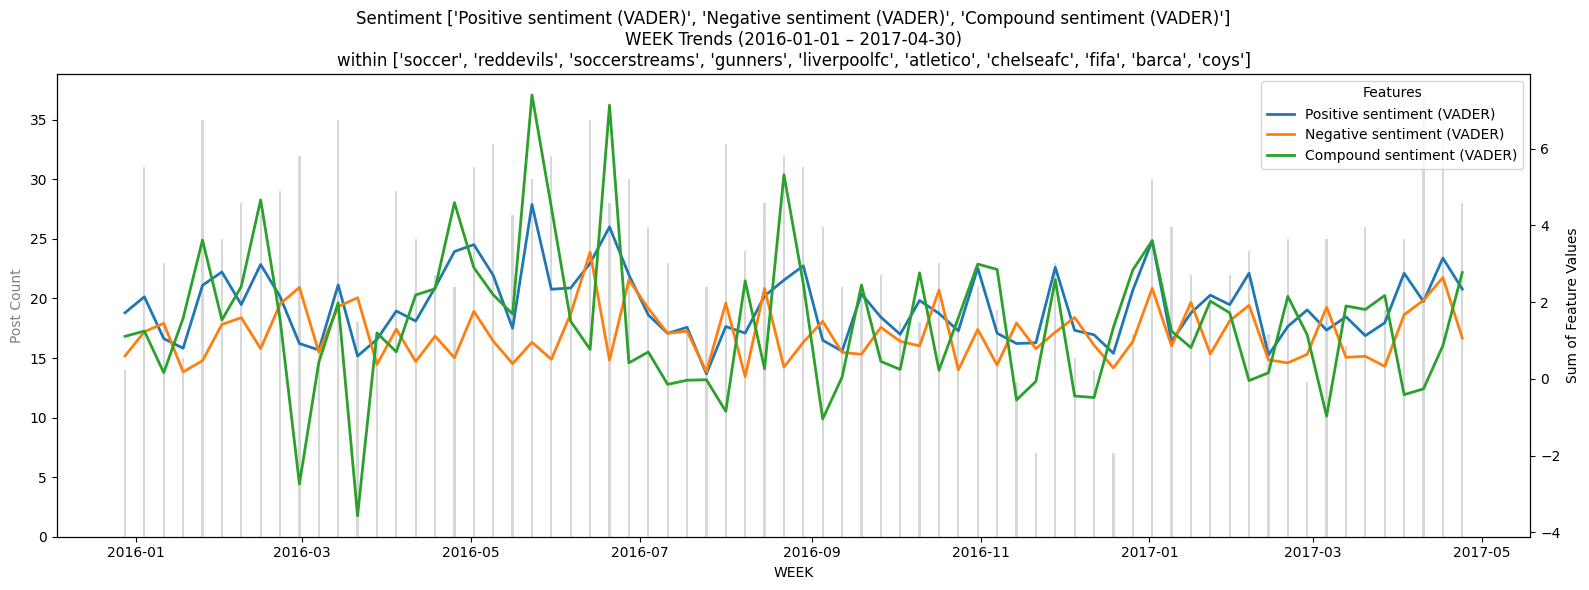

Body


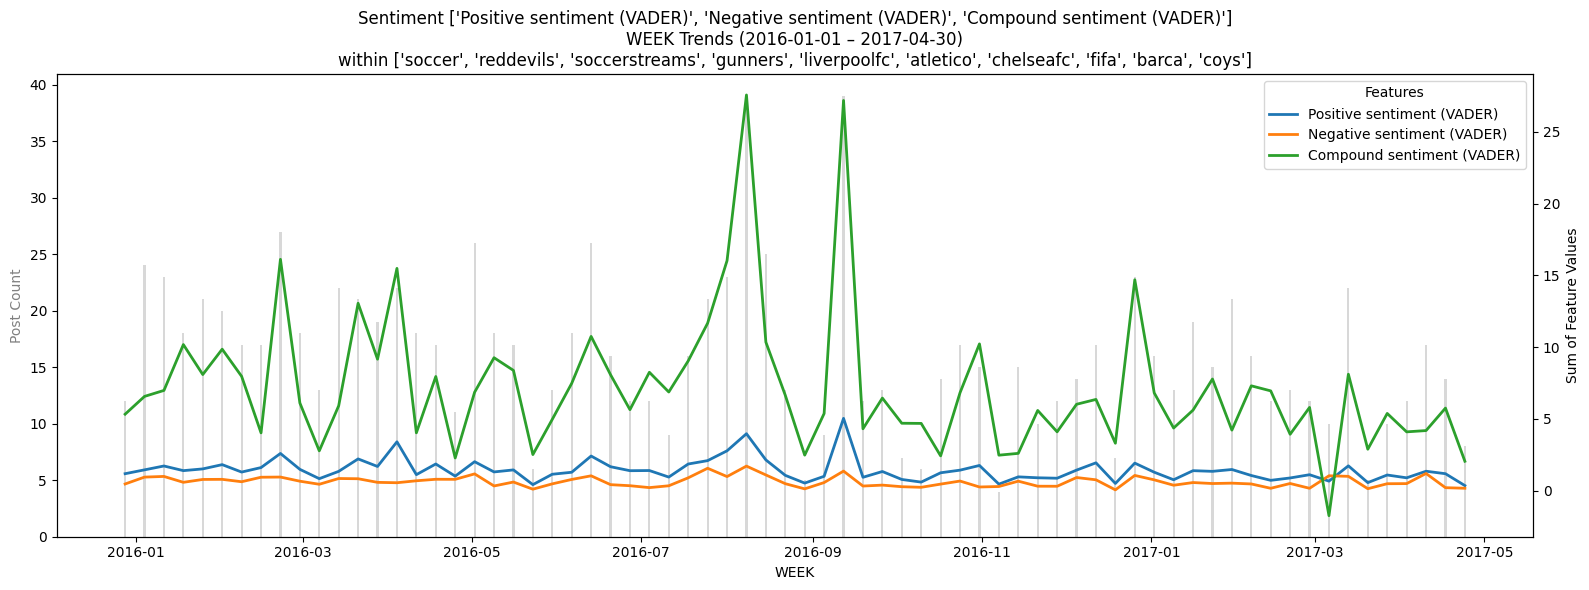

In [16]:
subreddits_list = [
    'soccer', 'reddevils', 'soccerstreams', 'gunners',
    'liverpoolfc', 'atletico', 'chelseafc', 'fifa', 'barca', 'coys'
]
start_time = "2016-01-01"
end_time = "2017-04-30"
features_list = [
    "Positive sentiment (VADER)",
    "Negative sentiment (VADER)",
    "Compound sentiment (VADER)"
]
period = "W"  # "D" for daily, "W" for weekly, "M" for monthly, "Q" for quarterly, "Y" for yearly
print("Title")
plot_subreddits_features_trend(df_title_prop, subreddits_list, start_time, end_time, features_list, period)
print("Body")
plot_subreddits_features_trend(df_body_prop, subreddits_list, start_time, end_time, features_list, period)